# pyCisTopic scATAC processing

Code based on https://pycistopic.readthedocs.io/en/latest/notebooks/human_cerebellum.html

In [1]:
import pycisTopic
import pandas as pd
import os
pycisTopic.__version__

'2.0a0'

In [ ]:
!ls /atac/COLO/bamfile_filtered

COLO829BL.filtered.bam	    COLO829_rep1.filtered.bam.csi
COLO829BL.filtered.bam.csi  COLO829_rep2.filtered.bam
COLO829_rep1.filtered.bam   COLO829_rep2.filtered.bam.csi


In [ ]:
!ls /atac/COLO/fragments/

COLO829BL.tsv.gz		COLO829_rep1_corrected.tsv.gz.tbi
COLO829BL_corrected.tsv.gz	COLO829_rep2.tsv.gz
COLO829BL_corrected.tsv.gz.tbi	COLO829_rep2_corrected.tsv.gz
COLO829_rep1.tsv.gz		COLO829_rep2_corrected.tsv.gz.tbi
COLO829_rep1_corrected.tsv.gz


In [5]:
os.chdir(os.getcwd())

In [6]:
out_dir = "outs"
os.makedirs(out_dir, exist_ok = True)

In [ ]:
import glob

def load_fragment_file(filepath, chunksize=100_000):
    chunks = []
    for chunk in pd.read_csv(
        filepath,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "barcode", "count"],
        comment="#",
        usecols=["barcode"],
        dtype={"barcode": "category"},
        chunksize=chunksize
    ):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

def load_fragments_from_directory(directory, pattern="*.tsv.gz"):
    files = glob.glob(os.path.join(directory, pattern))
    
    if not files:
        print(f"No files found matching '{pattern}' in {directory}")
        return pd.DataFrame()
    
    all_dfs = []
    for filepath in files:
        sample_name = os.path.basename(filepath).replace("_corrected.tsv.gz", "")
        print(f"Processing: {sample_name}...")
        df = load_fragment_file(filepath)
        df["barcode"] = df["barcode"].astype(str) + "-" + sample_name
        df["sample"] = sample_name
        all_dfs.append(df)
        print(f"  → {len(df):,} rows loaded")

    final_df = pd.concat(all_dfs, ignore_index=True)
    barcodes_df = final_df.drop_duplicates(subset="barcode").reset_index(drop=True)
    print(f"\nDone. {len(barcodes_df):,} unique barcodes across {len(files)} files.")
    return barcodes_df


barcodes_df = load_fragments_from_directory(
    directory="/atac/COLO/fragments/",
    pattern="*_corrected.tsv.gz"
)
barcodes_df

Processing: COLO829_rep1...
  → 94,887,675 rows loaded
Processing: COLO829BL...
  → 65,295,175 rows loaded
Processing: COLO829_rep2...
  → 106,281,054 rows loaded

Done. 7,147 unique barcodes across 3 files.


,barcode,sample
0,CCTAAGGAGTTTGTCG-COLO829_rep1,COLO829_rep1
1,CTAACCGGTAGGAGGA-COLO829_rep1,COLO829_rep1
2,GCAATACAGTCATGAA-COLO829_rep1,COLO829_rep1
3,TAGAGGCGTATATTCG-COLO829_rep1,COLO829_rep1
4,TGTTGAGCAGAATCTG-COLO829_rep1,COLO829_rep1
...,...,...
7142,CATAACCGTTTATGGC-COLO829_rep2,COLO829_rep2
7143,CTAGTAGCATGGTTAG-COLO829_rep2,COLO829_rep2
7144,CGTTATAGTTCCGGGT-COLO829_rep2,COLO829_rep2
7145,GGGATGGAGGCTTAAA-COLO829_rep2,COLO829_rep2


In [8]:
barcodes_df['sample'].value_counts()

COLO829_rep2    2665
COLO829_rep1    2374
COLO829BL       2108
Name: sample, dtype: int64

# Get pseudobulks

In [9]:
fragments_dict = {
    "COLO829BL":"fragments/COLO829BL_corrected.tsv.gz",
    "COLO829_rep1": "fragments/COLO829_rep1_corrected.tsv.gz",
    "COLO829_rep2": "fragments/COLO829_rep2_corrected.tsv.gz"
}

In [10]:
chromsizes = pd.read_table(
    "http://hgdownload.cse.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes",
    header = None,
    names = ["Chromosome", "End"]
)
chromsizes.insert(1, "Start", 0)
chromsizes.head()

,Chromosome,Start,End
0,chr1,0,248956422
1,chr2,0,242193529
2,chr3,0,198295559
3,chr4,0,190214555
4,chr5,0,181538259


In [11]:
barcodes_df = barcodes_df.set_index("barcode")

In [12]:
barcodes_df

,sample
barcode,
CCTAAGGAGTTTGTCG-COLO829_rep1,COLO829_rep1
CTAACCGGTAGGAGGA-COLO829_rep1,COLO829_rep1
GCAATACAGTCATGAA-COLO829_rep1,COLO829_rep1
TAGAGGCGTATATTCG-COLO829_rep1,COLO829_rep1
TGTTGAGCAGAATCTG-COLO829_rep1,COLO829_rep1
...,...
CATAACCGTTTATGGC-COLO829_rep2,COLO829_rep2
CTAGTAGCATGGTTAG-COLO829_rep2,COLO829_rep2
CGTTATAGTTCCGGGT-COLO829_rep2,COLO829_rep2


In [ ]:
from pycisTopic.pseudobulk_peak_calling import export_pseudobulk
os.makedirs(os.path.join(out_dir, "consensus_peak_calling"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bed_files"), exist_ok = True)
os.makedirs(os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bw_files"), exist_ok = True)


bw_paths, bed_paths = export_pseudobulk(
    input_data = barcodes_df,
    variable = "sample",
    sample_id_col = "sample",
    chromsizes = chromsizes,
    bed_path = os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bed_files"),
    bigwig_path = os.path.join(out_dir, "consensus_peak_calling/pseudobulk_bw_files"),
    path_to_fragments = fragments_dict,
    n_cpu = 15,
    normalize_bigwig = True,
    temp_dir = "/atac/revisiontmp",
    split_pattern = "-"
)

/opt/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-08 08:00:00,874	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-05-08 08:00:08,933 cisTopic     INFO     Splitting fragments by cell type.
2026-05-08 08:01:59,414 cisTopic     INFO     generating bigwig files


In [14]:
with open(os.path.join(out_dir, "consensus_peak_calling/bw_paths.tsv"), "wt") as f:
    for v in bw_paths:
        _ = f.write(f"{v}\t{bw_paths[v]}\n")

In [15]:
with open(os.path.join(out_dir, "consensus_peak_calling/bed_paths.tsv"), "wt") as f:
    for v in bed_paths:
        _ = f.write(f"{v}\t{bed_paths[v]}\n")

# Inferring the consensus peaks

In [ ]:
bw_paths = {}
with open(os.path.join(out_dir, "consensus_peak_calling/bw_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bw_paths.update({v: p})
        

In [ ]:
bed_paths = {}
with open(os.path.join(out_dir, "consensus_peak_calling/bed_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bed_paths.update({v: p})


In [18]:
bed_paths

{'COLO829_rep1': 'outs/consensus_peak_calling/pseudobulk_bed_files/COLO829_rep1.fragments.tsv.gz',
 'COLO829BL': 'outs/consensus_peak_calling/pseudobulk_bed_files/COLO829BL.fragments.tsv.gz',
 'COLO829_rep2': 'outs/consensus_peak_calling/pseudobulk_bed_files/COLO829_rep2.fragments.tsv.gz'}

In [ ]:
from pycisTopic.pseudobulk_peak_calling import peak_calling
macs_path = "macs2"

os.makedirs(os.path.join(out_dir, "consensus_peak_calling/MACS"), exist_ok = True)

narrow_peak_dict = peak_calling(
    macs_path = macs_path,
    bed_paths = bed_paths,
    outdir = os.path.join(os.path.join(out_dir, "consensus_peak_calling/MACS")),
    genome_size = 'hs',
    n_cpu = 15,
    input_format = 'BEDPE',
    shift = 73,
    ext_size = 146,
    keep_dup = 'all',
    q_value = 0.05,
    _temp_dir = '/tmp/ray_spill'
)

2026-05-08 08:05:30,519	INFO worker.py:1724 -- Started a local Ray instance.


(macs_call_peak_ray pid=3013738) 2026-05-08 08:05:32,939 cisTopic     INFO     Calling peaks for COLO829BL with macs2 callpeak --treatment outs/consensus_peak_calling/pseudobulk_bed_files/COLO829BL.fragments.tsv.gz --name COLO829BL  --outdir outs/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 --nomodel --shift 73 --extsize 146 --keep-dup all --call-summits --nolambda
(macs_call_peak_ray pid=3013738) 2026-05-08 08:09:14,661 cisTopic     INFO     COLO829BL done!
(macs_call_peak_ray pid=3013742) 2026-05-08 08:05:32,967 cisTopic     INFO     Calling peaks for COLO829_rep1 with macs2 callpeak --treatment outs/consensus_peak_calling/pseudobulk_bed_files/COLO829_rep1.fragments.tsv.gz --name COLO829_rep1  --outdir outs/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 --nomodel --shift 73 --extsize 146 --keep-dup all --call-summits --nolambda [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication,

In [ ]:
from pycisTopic.iterative_peak_calling import get_consensus_peaks
# Other param
peak_half_width=250
path_to_blacklist="hg38-blacklist.v2.bed" # update as needed
# Get consensus peaks
consensus_peaks = get_consensus_peaks(
    narrow_peaks_dict = narrow_peak_dict,
    peak_half_width = peak_half_width,
    chromsizes = chromsizes,
    path_to_blacklist = path_to_blacklist)

2026-05-08 08:11:26,953 cisTopic     INFO     Extending and merging peaks per class


/opt/venv/lib/python3.11/site-packages/pyranges/methods/intersection.py:52: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  scdf.loc[:, "Start"] = new_starts
/opt/venv/lib/python3.11/site-packages/pyranges/methods/intersection.py:53: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  scdf.loc[:, "End"] = new_ends
/opt/venv/lib/python3.11/site-packages/pyranges/methods/intersection.py:52: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use 

2026-05-08 08:11:57,985 cisTopic     INFO     Normalizing peak scores
2026-05-08 08:11:58,215 cisTopic     INFO     Merging peaks
Warning! Start and End columns now have different dtypes: int64 and int32
2026-05-08 08:12:45,950 cisTopic     INFO     Done!


In [21]:
consensus_peaks.to_bed(
    path = os.path.join(out_dir, "consensus_peak_calling/consensus_regions.bed"),
    keep =True,
    compression = 'infer',
    chain = False)

/opt/venv/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/opt/venv/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/opt/venv/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/opt/venv/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/opt/venv/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passin

# QC

In [22]:
!pycistopic tss gene_annotation_list --server http://may2024.archive.ensembl.org/ | grep Human

hsapiens_gene_ensembl	Human genes (GRCh38.p14)


In [23]:
!mkdir -p outs/qc
!pycistopic tss get_tss \
    --output outs/qc/tss.bed \
    --name "hsapiens_gene_ensembl" \
    --to-chrom-source ucsc \
    --server http://may2024.archive.ensembl.org/ \
    --ucsc hg38

- Get TSS annotation from Ensembl BioMart with the following settings:
  - biomart_name: "hsapiens_gene_ensembl"
  - biomart_host: "http://may2024.archive.ensembl.org/"
  - transcript_type: ['protein_coding']
  - use_cache: True
- Getting chromosome sizes and alias mapping for "hg38" from UCSC.
- Update chromosome names in TSS annotation to "ucsc" chromosome names.
- Writing TSS annotation BED file to "outs/qc/tss.bed".


In [24]:
!head outs/qc/tss.bed | column -t

/bin/bash: line 1: column: command not found
head: write error: Broken pipe


In [25]:
regions_bed_filename = os.path.join(out_dir, "consensus_peak_calling/consensus_regions.bed")
tss_bed_filename = os.path.join(out_dir, "qc", "tss.bed")

pycistopic_qc_commands_filename = "pycistopic_qc_commands.sh"

# Create text file with all pycistopic qc command lines.
with open(pycistopic_qc_commands_filename, "w") as fh:
    for sample, fragment_filename in fragments_dict.items():
        print(
            "pycistopic qc run",
            f"--fragments {fragment_filename}",
            f"--regions {regions_bed_filename}",
            f"--tss {tss_bed_filename}",
            f'--output {os.path.join(out_dir, "qc")}/{sample}',
            sep=" ",
            file=fh,
        )

In [26]:
!cat pycistopic_qc_commands.sh

pycistopic qc run --fragments fragments/COLO829BL_corrected.tsv.gz --regions outs/consensus_peak_calling/consensus_regions.bed --tss outs/qc/tss.bed --output outs/qc/COLO829BL
pycistopic qc run --fragments fragments/COLO829_rep1_corrected.tsv.gz --regions outs/consensus_peak_calling/consensus_regions.bed --tss outs/qc/tss.bed --output outs/qc/COLO829_rep1
pycistopic qc run --fragments fragments/COLO829_rep2_corrected.tsv.gz --regions outs/consensus_peak_calling/consensus_regions.bed --tss outs/qc/tss.bed --output outs/qc/COLO829_rep2


**In command line**
```
chmod u+x pycistopic_qc_commands.sh
apptainer run -B $VSC_DATA/ pycistopic_2.0a.sif /atac/COLO/pycistopic_qc_commands.sh
```

Alternatively, in case you run into issues with kde function, run more recent pycistopic version


In [27]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

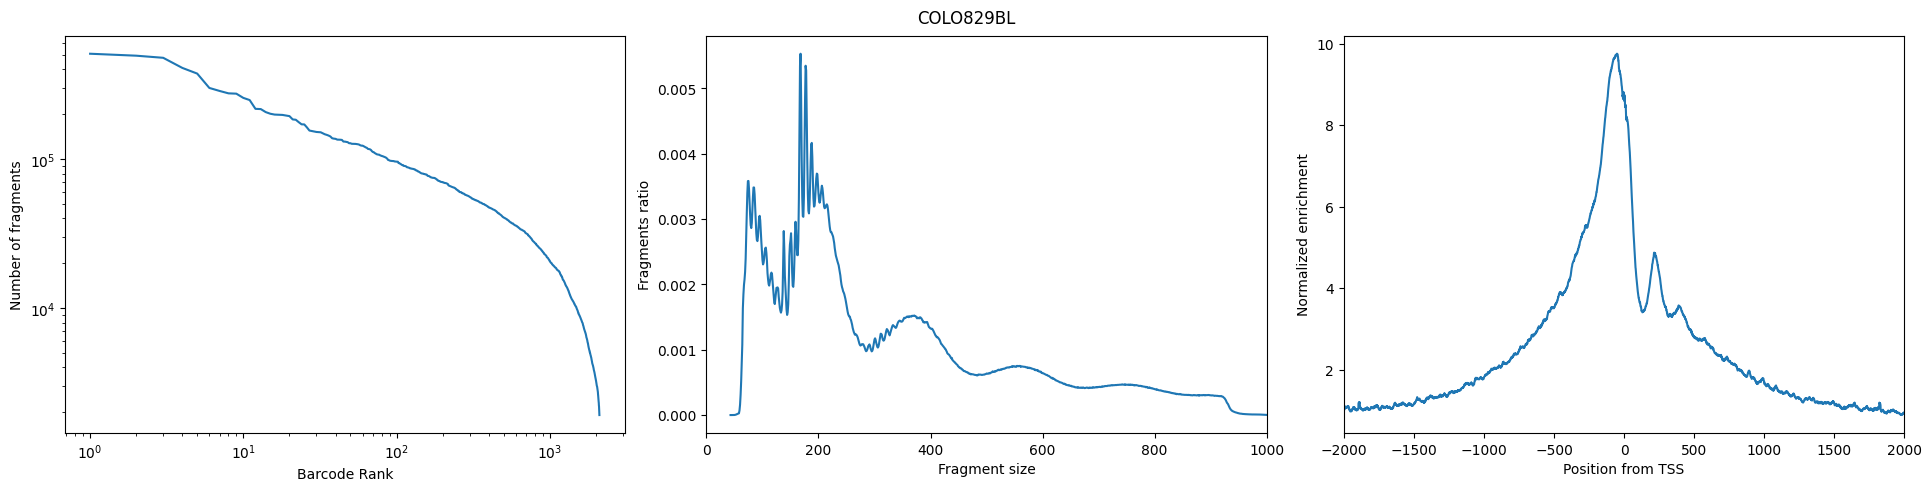

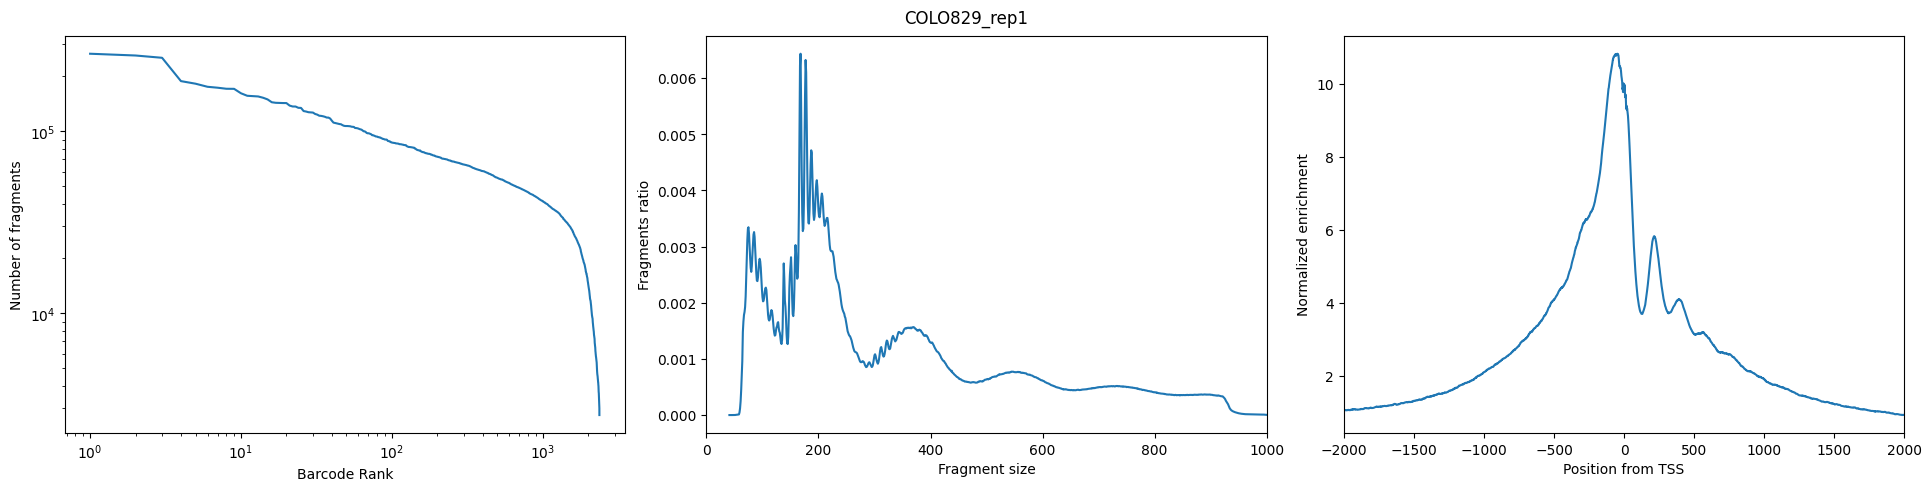

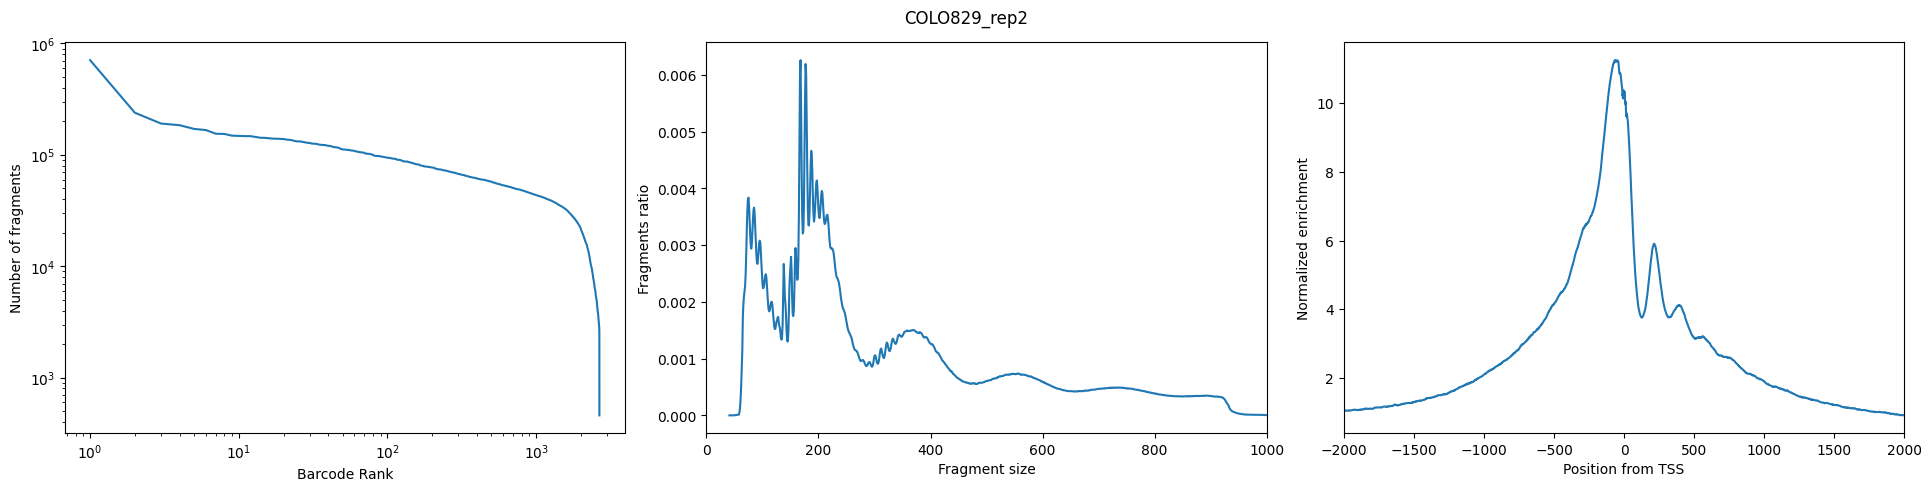

In [28]:
for sample_id in fragments_dict:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = "outs/qc"
    )
    fig.savefig(f"outs/qc/{sample_id}_ATAC_QC_stats.pdf",dpi=300)
    plt.show() 
    plt.close(fig) 

In [29]:
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_dict:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir = "outs/qc",
            unique_fragments_threshold = 1000, # use automatic thresholding when you specify None
            tss_enrichment_threshold = 7.5, # use automatic thresholding
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

COLO829BL:
	Using user-defined threshold for unique fragments: 1000
	Using user-defined threshold for TSS enrichment: 7.5
COLO829_rep1:
	Using user-defined threshold for unique fragments: 1000
	Using user-defined threshold for TSS enrichment: 7.5
COLO829_rep2:
	Using user-defined threshold for unique fragments: 1000
	Using user-defined threshold for TSS enrichment: 7.5


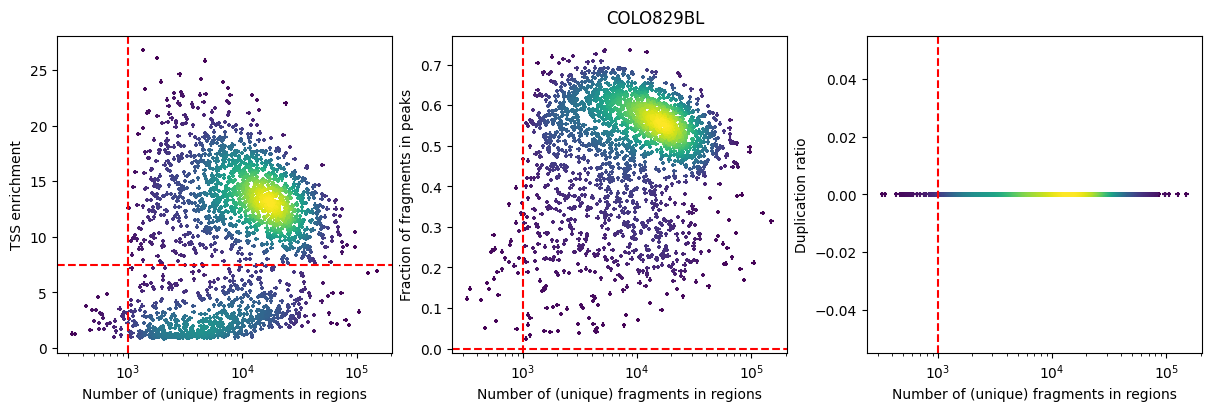

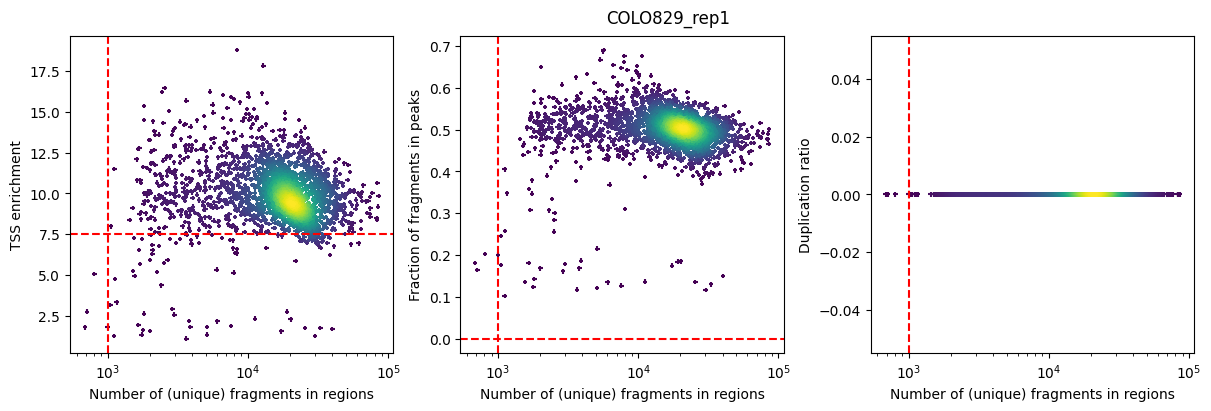

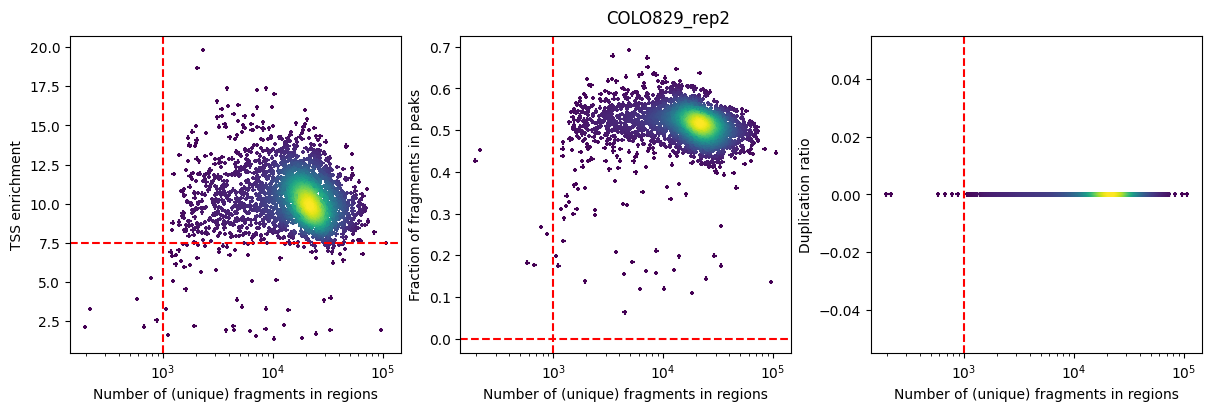

In [30]:
for sample_id in fragments_dict:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = "outs/qc",
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,
        **sample_id_to_thresholds[sample_id] 
    )
    fig.savefig(f"outs/qc/{sample_id}_ATAC_QC_cell_stats.pdf",dpi=300)
    plt.show() 
    plt.close(fig)

# Creating a cisTopic object

In [ ]:
path_to_regions = os.path.join(out_dir, "consensus_peak_calling/consensus_regions.bed")
path_to_blacklist="hg38-blacklist.v2.bed"
pycistopic_qc_output_dir = "outs/qc"

from pycisTopic.cistopic_class import create_cistopic_object_from_fragments
import polars as pl

cistopic_obj_list = []
for sample_id in fragments_dict:
    sample_metrics = pl.read_parquet(
        os.path.join(pycistopic_qc_output_dir, f'{sample_id}.fragments_stats_per_cb.parquet')
    ).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample_id] ]
    cistopic_obj = create_cistopic_object_from_fragments(
        path_to_fragments = fragments_dict[sample_id],
        path_to_regions = path_to_regions,
        path_to_blacklist = path_to_blacklist,
        metrics = sample_metrics,
        valid_bc = sample_id_to_barcodes_passing_filters[sample_id],
        n_cpu = 5,
        project = sample_id,
        split_pattern = '-'
    )
    cistopic_obj_list.append(cistopic_obj)

2026-05-08 08:19:10,585 cisTopic     INFO     Reading data for COLO829BL
2026-05-08 08:19:38,385 cisTopic     INFO     metrics provided!
2026-05-08 08:19:41,069 cisTopic     INFO     Counting fragments in regions


2026-05-08 08:19:44,216	INFO worker.py:1724 -- Started a local Ray instance.


2026-05-08 08:19:52,851 cisTopic     INFO     Creating fragment matrix
2026-05-08 08:20:01,911 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-05-08 08:20:04,164 cisTopic     INFO     Removing blacklisted regions
2026-05-08 08:20:05,121 cisTopic     INFO     Creating CistopicObject
2026-05-08 08:20:05,687 cisTopic     INFO     Done!
2026-05-08 08:20:05,723 cisTopic     INFO     Reading data for COLO829_rep1
2026-05-08 08:20:45,224 cisTopic     INFO     metrics provided!
2026-05-08 08:20:48,679 cisTopic     INFO     Counting fragments in regions


2026-05-08 08:20:51,926	INFO worker.py:1724 -- Started a local Ray instance.


2026-05-08 08:21:06,798 cisTopic     INFO     Creating fragment matrix
2026-05-08 08:21:25,803 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-05-08 08:21:29,709 cisTopic     INFO     Removing blacklisted regions
2026-05-08 08:21:30,635 cisTopic     INFO     Creating CistopicObject
2026-05-08 08:21:31,544 cisTopic     INFO     Done!
2026-05-08 08:21:31,602 cisTopic     INFO     Reading data for COLO829_rep2
2026-05-08 08:22:16,527 cisTopic     INFO     metrics provided!
2026-05-08 08:22:20,100 cisTopic     INFO     Counting fragments in regions


2026-05-08 08:22:23,409	INFO worker.py:1724 -- Started a local Ray instance.


2026-05-08 08:22:40,478 cisTopic     INFO     Creating fragment matrix
2026-05-08 08:23:02,005 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-05-08 08:23:06,472 cisTopic     INFO     Removing blacklisted regions
2026-05-08 08:23:07,406 cisTopic     INFO     Creating CistopicObject
2026-05-08 08:23:08,428 cisTopic     INFO     Done!


In [32]:
cistopic_obj = cistopic_obj_list[0]
print(cistopic_obj)

CistopicObject from project COLO829BL with n_cells × n_regions = 1442 × 361871


In [33]:
from pycisTopic.cistopic_class import merge
cistopic_obj = merge(cistopic_obj_list)

2026-05-08 08:23:11,279 cisTopic     INFO     cisTopic object 1 merged
2026-05-08 08:23:15,314 cisTopic     INFO     cisTopic object 2 merged


In [34]:
cistopic_obj

In [35]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,log10_unique_fragments_in_peaks_count,fraction_of_fragments_in_peaks,duplication_count,duplication_ratio,nucleosome_signal,tss_enrichment,pdf_values_for_tss_enrichment,pdf_values_for_fraction_of_fragments_in_peaks,pdf_values_for_duplication_ratio,barcode
CGACCTTAGCCAAACG-COLO829BL___COLO829BL,39400,4.595496,29415,4.468569,COLO829BL,227,65438,4.815837,65438,4.815837,...,4.575165,0.574544,0,0.0,1.680006,13.919329,0.035191,1.377781,2.414798e+13,CGACCTTAGCCAAACG
GTAACCACAATTACCC-COLO829BL___COLO829BL,27708,4.442605,22003,4.342482,COLO829BL,370,49904,4.698144,49904,4.698144,...,4.421143,0.528435,0,0.0,2.034324,11.310762,0.071113,3.345470,4.148058e+13,GTAACCACAATTACCC
TGACGGATCTACCTGA-COLO829BL___COLO829BL,30819,4.488819,25633,4.408799,COLO829BL,222,66081,4.820083,66081,4.820083,...,4.466690,0.443198,0,0.0,2.100913,8.401286,0.026994,1.246256,3.652514e+13,TGACGGATCTACCTGA
TTTATCCGTTGTAACC-COLO829BL___COLO829BL,18798,4.274112,15386,4.187126,COLO829BL,724,30755,4.487930,30755,4.487930,...,4.251590,0.580296,0,0.0,1.810568,13.432658,0.094064,3.784032,5.368387e+13,TTTATCCGTTGTAACC
GTTGAGGTCAGGTTCC-COLO829BL___COLO829BL,27196,4.434505,21840,4.339253,COLO829BL,364,50141,4.700202,50141,4.700202,...,4.412964,0.516125,0,0.0,2.385235,11.472113,0.073858,3.295732,4.231705e+13,GTTGAGGTCAGGTTCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGTTCGCTCCGCCATG-COLO829_rep2___COLO829_rep2,1274,3.105169,1250,3.09691,COLO829_rep2,2663,2600,3.415140,2600,3.415140,...,3.088136,0.470769,0,0.0,2.085828,8.788053,0.010244,0.231623,4.002418e+12,AGTTCGCTCCGCCATG
GTTGAATCAGGTTACA-COLO829_rep2___COLO829_rep2,4076,3.610234,3889,3.589838,COLO829_rep2,2367,9581,3.981456,9581,3.981456,...,3.593397,0.409143,0,0.0,1.968487,9.423928,0.048471,0.139195,1.905808e+13,GTTGAATCAGGTTACA
ATGCAATCATCCGCTA-COLO829_rep2___COLO829_rep2,1284,3.108565,1156,3.062958,COLO829_rep2,2659,2782,3.444513,2782,3.444513,...,3.086004,0.437815,0,0.0,3.993528,8.307546,0.008375,0.108939,3.923059e+12,ATGCAATCATCCGCTA
CAGTCTATCCTGAAGG-COLO829_rep2___COLO829_rep2,2036,3.308778,1987,3.298198,COLO829_rep2,2610,3764,3.575765,3764,3.575765,...,3.288473,0.515940,0,0.0,2.151773,9.114998,0.028958,1.351343,1.186828e+13,CAGTCTATCCTGAAGG


In [36]:
cistopic_obj.cell_data.sample_id.value_counts()

COLO829_rep2    2578
COLO829_rep1    2253
COLO829BL       1442
Name: sample_id, dtype: int64

# compare with the cells from RNA

In [ ]:
import scanpy as sc

rna = sc.read_h5ad('/COLO829_adata_05052026.h5ad') # change path as needed
rna

AnnData object with n_obs × n_vars = 5183 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'outlier', 'mt_outlier', 'ribo_outlier', 'phase', 'S_score', 'G2M_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_pre_harmony'
    varm: 'PCs'
    layers: 'counts', 'log_counts'
    obsp: 'connectivities', 'distances'

In [38]:
rna.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb,outlier,mt_outlier,ribo_outlier,phase,S_score,G2M_score
AAACCAACAAGGTAAC-COLO829BL,COLO829BL,4131,8.326517,21395.0,9.970960,26.422061,3.271792,2.009815,0.0,False,False,False,G1,-0.387284,-0.417121
AAACCGCGTACCAGGT-COLO829BL,COLO829BL,4500,8.412055,20423.5,9.924491,16.583837,6.208534,2.085833,0.0,False,False,False,G2M,-0.042651,1.363847
AAACCGCGTTCCGCAC-COLO829BL,COLO829BL,4315,8.370084,18555.0,9.828548,17.078954,0.711399,1.794665,0.0,False,False,False,G2M,0.165291,0.219088
AAACCGCGTTGCTGGG-COLO829BL,COLO829BL,1451,7.280697,5508.0,8.614139,31.989833,3.031954,3.721859,0.0,False,False,False,G1,-0.205560,-0.462720
AAACCGGCATGCTCCC-COLO829BL,COLO829BL,5112,8.539542,26430.5,10.182312,14.982690,5.716880,3.613250,0.0,False,False,False,G2M,0.296752,0.497705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGAAGAGCCGGA-COLO829_rep2,COLO829_rep2,3254,8.087948,7043.0,8.859932,13.687349,3.549624,1.263666,0.0,False,False,False,G2M,0.539521,0.553274
TTTGTGAAGCAGGTGG-COLO829_rep2,COLO829_rep2,2916,7.978311,6322.0,8.751949,16.118317,6.849098,1.202151,0.0,False,False,False,S,0.684618,0.448833
TTTGTGAAGTTTAACG-COLO829_rep2,COLO829_rep2,2243,7.716015,4632.5,8.441068,18.866703,8.634646,1.748516,0.0,False,False,False,G1,-0.152529,-0.371827
TTTGTGGCATGTTGGC-COLO829_rep2,COLO829_rep2,3808,8.245122,9219.5,9.129185,15.901079,3.785455,0.905689,0.0,False,False,False,S,1.231007,0.728113


In [ ]:

atac_CB = pd.read_csv('/barcodes/cellranger_arc_atac.737K-arc-v1.txt.gz', header=None)
rna_CB  = pd.read_csv('/barcodes/cellranger_arc_rna.737K-arc-v1.txt.gz',  header=None)
rna_CB.rename(columns={0:  'rna_CB'},  inplace=True)
atac_CB.rename(columns={0: 'atac_CB'}, inplace=True)
df_merged = pd.concat([rna_CB, atac_CB], axis=1)

rna.obs['base_index'] = rna.obs.index.str.split('-').str[0]
mapping_dict = pd.Series(df_merged['atac_CB'].values, index=df_merged['rna_CB']).to_dict()
rna.obs['atac_CB'] = rna.obs['base_index'].map(mapping_dict)


# structure: atac_CB + '-' + sample + '___' + sample
rna.obs['atac_index'] = (
    rna.obs['atac_CB'].astype(str) + '-' +
    rna.obs['sample'].astype(str)  + '___' +
    rna.obs['sample'].astype(str)
)

# 4. Map all rna.obs columns → adata.obs via atac_index
cols_to_map = [c for c in rna.obs.columns if c not in ['atac_index', 'atac_CB', 'base_index']]

rna_obs_indexed = rna.obs.set_index('atac_index')

for col in cols_to_map:
    cistopic_obj.cell_data[col] = cistopic_obj.cell_data.index.map(rna_obs_indexed[col])

print(f"Mapped {len(cols_to_map)} columns to cistopic_obj.cell_data")
print(f"Matched: {cistopic_obj.cell_data[cols_to_map[0]].notna().sum()} / {len(cistopic_obj.cell_data)} cells")

Mapped 15 columns to cistopic_obj.cell_data
Matched: 4620 / 6273 cells


In [43]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,pct_counts_ribo,pct_counts_hb,outlier,mt_outlier,ribo_outlier,phase,S_score,G2M_score,base_index,atac_CB
CGACCTTAGCCAAACG-COLO829BL___COLO829BL,39400,4.595496,29415,4.468569,COLO829BL,227,65438,4.815837,65438,4.815837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTAACCACAATTACCC-COLO829BL___COLO829BL,27708,4.442605,22003,4.342482,COLO829BL,370,49904,4.698144,49904,4.698144,...,2.113990,0.0,False,False,False,G1,-0.276628,-0.452426,GATTGGCGTTCAAGAT,GTAACCACAATTACCC
TGACGGATCTACCTGA-COLO829BL___COLO829BL,30819,4.488819,25633,4.408799,COLO829BL,222,66081,4.820083,66081,4.820083,...,1.751306,0.0,False,False,False,G1,-0.012656,-0.188966,CGCTTCTAGTTAGTTG,TGACGGATCTACCTGA
TTTATCCGTTGTAACC-COLO829BL___COLO829BL,18798,4.274112,15386,4.187126,COLO829BL,724,30755,4.487930,30755,4.487930,...,2.085931,0.0,False,False,False,S,0.614542,0.183744,ATTTAGCCAATACTGT,TTTATCCGTTGTAACC
GTTGAGGTCAGGTTCC-COLO829BL___COLO829BL,27196,4.434505,21840,4.339253,COLO829BL,364,50141,4.700202,50141,4.700202,...,4.076973,0.0,False,False,False,G1,-0.259912,-0.379561,GAACCAAAGGATTGAG,GTTGAGGTCAGGTTCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGTTCGCTCCGCCATG-COLO829_rep2___COLO829_rep2,1274,3.105169,1250,3.09691,COLO829_rep2,2663,2600,3.415140,2600,3.415140,...,1.311260,0.0,False,False,False,G1,-0.388261,-0.332489,GGTTACTAGCACTAGT,AGTTCGCTCCGCCATG
GTTGAATCAGGTTACA-COLO829_rep2___COLO829_rep2,4076,3.610234,3889,3.589838,COLO829_rep2,2367,9581,3.981456,9581,3.981456,...,0.873444,0.0,False,False,False,G1,-0.001481,-0.361263,CCAACCCGTTGCCTCA,GTTGAATCAGGTTACA
ATGCAATCATCCGCTA-COLO829_rep2___COLO829_rep2,1284,3.108565,1156,3.062958,COLO829_rep2,2659,2782,3.444513,2782,3.444513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGTCTATCCTGAAGG-COLO829_rep2___COLO829_rep2,2036,3.308778,1987,3.298198,COLO829_rep2,2610,3764,3.575765,3764,3.575765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
import pickle
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

# Add metadata to cistopic object

In [45]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,pct_counts_ribo,pct_counts_hb,outlier,mt_outlier,ribo_outlier,phase,S_score,G2M_score,base_index,atac_CB
CGACCTTAGCCAAACG-COLO829BL___COLO829BL,39400,4.595496,29415,4.468569,COLO829BL,227,65438,4.815837,65438,4.815837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTAACCACAATTACCC-COLO829BL___COLO829BL,27708,4.442605,22003,4.342482,COLO829BL,370,49904,4.698144,49904,4.698144,...,2.113990,0.0,False,False,False,G1,-0.276628,-0.452426,GATTGGCGTTCAAGAT,GTAACCACAATTACCC
TGACGGATCTACCTGA-COLO829BL___COLO829BL,30819,4.488819,25633,4.408799,COLO829BL,222,66081,4.820083,66081,4.820083,...,1.751306,0.0,False,False,False,G1,-0.012656,-0.188966,CGCTTCTAGTTAGTTG,TGACGGATCTACCTGA
TTTATCCGTTGTAACC-COLO829BL___COLO829BL,18798,4.274112,15386,4.187126,COLO829BL,724,30755,4.487930,30755,4.487930,...,2.085931,0.0,False,False,False,S,0.614542,0.183744,ATTTAGCCAATACTGT,TTTATCCGTTGTAACC
GTTGAGGTCAGGTTCC-COLO829BL___COLO829BL,27196,4.434505,21840,4.339253,COLO829BL,364,50141,4.700202,50141,4.700202,...,4.076973,0.0,False,False,False,G1,-0.259912,-0.379561,GAACCAAAGGATTGAG,GTTGAGGTCAGGTTCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGTTCGCTCCGCCATG-COLO829_rep2___COLO829_rep2,1274,3.105169,1250,3.09691,COLO829_rep2,2663,2600,3.415140,2600,3.415140,...,1.311260,0.0,False,False,False,G1,-0.388261,-0.332489,GGTTACTAGCACTAGT,AGTTCGCTCCGCCATG
GTTGAATCAGGTTACA-COLO829_rep2___COLO829_rep2,4076,3.610234,3889,3.589838,COLO829_rep2,2367,9581,3.981456,9581,3.981456,...,0.873444,0.0,False,False,False,G1,-0.001481,-0.361263,CCAACCCGTTGCCTCA,GTTGAATCAGGTTACA
ATGCAATCATCCGCTA-COLO829_rep2___COLO829_rep2,1284,3.108565,1156,3.062958,COLO829_rep2,2659,2782,3.444513,2782,3.444513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGTCTATCCTGAAGG-COLO829_rep2___COLO829_rep2,2036,3.308778,1987,3.298198,COLO829_rep2,2610,3764,3.575765,3764,3.575765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
import pandas as pd

#cistopic_obj.add_cell_data(rna_cell_type) # use data from rna for cell type
pickle.dump(
    cistopic_obj,
    open(os.path.join(out_dir, "cistopic_obj.pkl"), "wb")
)

In [47]:
cistopic_obj.cell_data


,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,pct_counts_ribo,pct_counts_hb,outlier,mt_outlier,ribo_outlier,phase,S_score,G2M_score,base_index,atac_CB
CGACCTTAGCCAAACG-COLO829BL___COLO829BL,39400,4.595496,29415,4.468569,COLO829BL,227,65438,4.815837,65438,4.815837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTAACCACAATTACCC-COLO829BL___COLO829BL,27708,4.442605,22003,4.342482,COLO829BL,370,49904,4.698144,49904,4.698144,...,2.113990,0.0,False,False,False,G1,-0.276628,-0.452426,GATTGGCGTTCAAGAT,GTAACCACAATTACCC
TGACGGATCTACCTGA-COLO829BL___COLO829BL,30819,4.488819,25633,4.408799,COLO829BL,222,66081,4.820083,66081,4.820083,...,1.751306,0.0,False,False,False,G1,-0.012656,-0.188966,CGCTTCTAGTTAGTTG,TGACGGATCTACCTGA
TTTATCCGTTGTAACC-COLO829BL___COLO829BL,18798,4.274112,15386,4.187126,COLO829BL,724,30755,4.487930,30755,4.487930,...,2.085931,0.0,False,False,False,S,0.614542,0.183744,ATTTAGCCAATACTGT,TTTATCCGTTGTAACC
GTTGAGGTCAGGTTCC-COLO829BL___COLO829BL,27196,4.434505,21840,4.339253,COLO829BL,364,50141,4.700202,50141,4.700202,...,4.076973,0.0,False,False,False,G1,-0.259912,-0.379561,GAACCAAAGGATTGAG,GTTGAGGTCAGGTTCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGTTCGCTCCGCCATG-COLO829_rep2___COLO829_rep2,1274,3.105169,1250,3.09691,COLO829_rep2,2663,2600,3.415140,2600,3.415140,...,1.311260,0.0,False,False,False,G1,-0.388261,-0.332489,GGTTACTAGCACTAGT,AGTTCGCTCCGCCATG
GTTGAATCAGGTTACA-COLO829_rep2___COLO829_rep2,4076,3.610234,3889,3.589838,COLO829_rep2,2367,9581,3.981456,9581,3.981456,...,0.873444,0.0,False,False,False,G1,-0.001481,-0.361263,CCAACCCGTTGCCTCA,GTTGAATCAGGTTACA
ATGCAATCATCCGCTA-COLO829_rep2___COLO829_rep2,1284,3.108565,1156,3.062958,COLO829_rep2,2659,2782,3.444513,2782,3.444513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGTCTATCCTGAAGG-COLO829_rep2___COLO829_rep2,2036,3.308778,1987,3.298198,COLO829_rep2,2610,3764,3.575765,3764,3.575765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
cistopic_obj.cell_data.sample_id.value_counts()

COLO829_rep2    2578
COLO829_rep1    2253
COLO829BL       1442
Name: sample_id, dtype: int64

# CisTopic running

In [49]:
!wget https://github.com/mimno/Mallet/releases/download/v202108/Mallet-202108-bin.tar.gz
!tar -xf Mallet-202108-bin.tar.gz

/bin/bash: line 1: wget: command not found


In [ ]:
!cat 03b_pycistopic_modelling.py

In [ ]:
!cat 03a_pycistopic_modelling.slurm 

In [ ]:
!mkdir -p /ray_spill/mallet/tutorial/

and I submitted 03a_pycistopic_modelling.slurm  as a slurm job 
```
sbatch 03a_pycistopic_modelling.slurm
```

In [53]:
pip list

Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                     